In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print("Path to dataset files:", path)

100%|██████████| 4.29G/4.29G [01:01<00:00, 75.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/versions/8


In [ ]:
import os

print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['2019-Oct.csv', '2019-Nov.csv']


In [ ]:
import pandas as pd
import os

oct_file = os.path.join(path, "2019-Oct.csv")

df = pd.read_csv(oct_file, nrows=200000)

print("Dataset loaded successfully")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully
Shape: (200000, 9)

First 5 rows:
                event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4

In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nEvent types:")
print(df["event_type"].value_counts())

print("\nUnique users:")
print(df["user_id"].nunique())

print("\nUnique sessions:")
print(df["user_session"].nunique())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape:
(200000, 9)

Column names:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

First 5 rows:
                event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               el

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from itertools import combinations


In [ ]:
oct_file = os.path.join(path, "2019-Oct.csv")

df = pd.read_csv(
    oct_file,
    nrows=2000000
)

print("Dataset loaded successfully")
print("Shape:", df.shape)

print(df.head())

Dataset loaded successfully
Shape: (2000000, 9)
                event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032d

In [ ]:
required_columns = [
    "event_time",
    "event_type",
    "user_id",
    "user_session"
]

data = df[required_columns].copy()

print(data.head())
print("\nShape:", data.shape)

                event_time event_type    user_id  \
0  2019-10-01 00:00:00 UTC       view  541312140   
1  2019-10-01 00:00:00 UTC       view  554748717   
2  2019-10-01 00:00:01 UTC       view  519107250   
3  2019-10-01 00:00:01 UTC       view  550050854   
4  2019-10-01 00:00:04 UTC       view  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032dfed738c  
1  9333dfbd-b87a-4708-9857-6336556b0fcc  
2  566511c2-e2e3-422b-b695-cf8e6e792ca8  
3  7c90fc70-0e80-4590-96f3-13c02c18c713  
4  c6bd7419-2748-4c56-95b4-8cec9ff8b80d  

Shape: (2000000, 4)


In [ ]:
# Check missing values
print("Missing values:")
print(data.isnull().sum())

# Remove missing values
data = data.dropna()

# Remove duplicate rows
data = data.drop_duplicates()

print("\nShape after cleaning:", data.shape)

Missing values:
event_time      0
event_type      0
user_id         0
user_session    0
dtype: int64

Shape after cleaning: (1998965, 4)


In [ ]:
transactions = (
    data.groupby("user_session")["event_type"]
        .apply(lambda x: list(set(x)))
        .tolist()
)

print("Total transactions:", len(transactions))

print("\nFirst 10 transactions:")
for t in transactions[:10]:
    print(t)

Total transactions: 446930

First 10 transactions:
['view']
['view']
['view']
['view']
['view']
['view']
['view']
['view']
['view']
['view']


In [ ]:
useful_transactions = [
    t for t in transactions
    if len(t) >= 2
]

print("Useful transactions:", len(useful_transactions))

print("\nFirst 10 useful transactions:")
for t in useful_transactions[:10]:
    print(t)

Useful transactions: 36375

First 10 useful transactions:
['purchase', 'view']
['purchase', 'view']
['purchase', 'cart', 'view']
['purchase', 'cart', 'view']
['purchase', 'cart', 'view']
['purchase', 'cart', 'view']
['purchase', 'view']
['purchase', 'view']
['cart', 'view']
['purchase', 'view']


In [ ]:
from itertools import combinations

min_support = 0.01
frequent_itemsets = {}

items = sorted(set(item for t in transactions for item in t))

for size in range(1, len(items) + 1):

    for combo in combinations(items, size):

        count = 0

        for transaction in transactions:

            if set(combo).issubset(set(transaction)):
                count += 1

        support = count / len(transactions)

        if support >= min_support:
            frequent_itemsets[combo] = support

print("Frequent Itemsets:")

for itemset, support in frequent_itemsets.items():
    print(itemset, "Support:", round(support, 4))

Frequent Itemsets:
('cart',) Support: 0.0402
('purchase',) Support: 0.0641
('view',) Support: 0.9997
('cart', 'purchase') Support: 0.0227
('cart', 'view') Support: 0.0401
('purchase', 'view') Support: 0.0639
('cart', 'purchase', 'view') Support: 0.0226


In [ ]:
rules = []

for itemset, support_ab in frequent_itemsets.items():

    if len(itemset) == 2:

        A = (itemset[0],)
        B = (itemset[1],)

        # A -> B
        confidence = support_ab / frequent_itemsets[A]
        lift = confidence / frequent_itemsets[B]

        rules.append([
            A[0], B[0], support_ab, confidence, lift
        ])

        # B -> A
        confidence = support_ab / frequent_itemsets[B]
        lift = confidence / frequent_itemsets[A]

        rules.append([
            B[0], A[0], support_ab, confidence, lift
        ])

rules_df = pd.DataFrame(
    rules,
    columns=[
        "Antecedent",
        "Consequent",
        "Support",
        "Confidence",
        "Lift"
    ]
)

print(rules_df.round(4))

  Antecedent Consequent  Support  Confidence    Lift
0       cart   purchase   0.0227      0.5633  8.7900
1   purchase       cart   0.0227      0.3537  8.7900
2       cart       view   0.0401      0.9974  0.9977
3       view       cart   0.0401      0.0401  0.9977
4   purchase       view   0.0639      0.9963  0.9966
5       view   purchase   0.0639      0.0639  0.9966


In [ ]:
strong_rules = rules_df[rules_df["Lift"] > 1]

print("Strong Association Rules:")
print(strong_rules.round(4))

Strong Association Rules:
  Antecedent Consequent  Support  Confidence  Lift
0       cart   purchase   0.0227      0.5633  8.79
1   purchase       cart   0.0227      0.3537  8.79


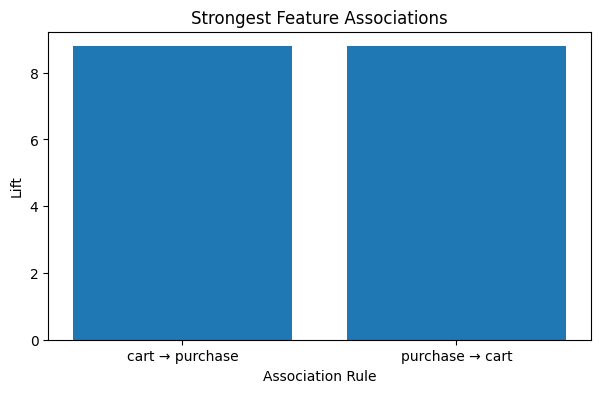

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    strong_rules["Antecedent"] + " → " + strong_rules["Consequent"],
    strong_rules["Lift"]
)

plt.title("Strongest Feature Associations")
plt.xlabel("Association Rule")
plt.ylabel("Lift")

plt.show()

In [ ]:
print("UI Redesign Recommendations:\n")

for _, row in strong_rules.iterrows():

    if row["Antecedent"] == "cart" and row["Consequent"] == "purchase":
        print(
            "• Cart and Purchase are strongly associated."
        )
        print(
            "  Recommendation: Make the Cart → Purchase flow "
            "simple, clear and require fewer steps."
        )

    elif row["Antecedent"] == "purchase" and row["Consequent"] == "cart":
        print(
            "• Purchase and Cart are strongly associated."
        )
        print(
            "  Recommendation: Keep cart access clearly visible "
            "during the shopping and checkout process."
        )

UI Redesign Recommendations:

• Cart and Purchase are strongly associated.
  Recommendation: Make the Cart → Purchase flow simple, clear and require fewer steps.
• Purchase and Cart are strongly associated.
  Recommendation: Keep cart access clearly visible during the shopping and checkout process.


In [ ]:
best_rule = strong_rules.sort_values(
    "Lift",
    ascending=False
).iloc[0]

print("PROJECT RESULT")
print("-" * 40)

print("Strongest Rule:",
      best_rule["Antecedent"],
      "→",
      best_rule["Consequent"])

print("Support:", round(best_rule["Support"], 4))
print("Confidence:", round(best_rule["Confidence"], 4))
print("Lift:", round(best_rule["Lift"], 4))

PROJECT RESULT
----------------------------------------
Strongest Rule: cart → purchase
Support: 0.0227
Confidence: 0.5633
Lift: 8.79


In [ ]:
import random

random.seed(42)
random.shuffle(transactions)

split = int(0.8 * len(transactions))

train = transactions[:split]
test = transactions[split:]

print("Training sessions:", len(train))
print("Testing sessions:", len(test))

Training sessions: 357544
Testing sessions: 89386


In [ ]:
cart_count = 0
cart_purchase_count = 0

for t in test:

    if "cart" in t:
        cart_count += 1

        if "purchase" in t:
            cart_purchase_count += 1

test_confidence = cart_purchase_count / cart_count

print("Cart sessions:", cart_count)
print("Cart + Purchase sessions:", cart_purchase_count)
print("Test Confidence:", round(test_confidence, 4))

Cart sessions: 3585
Cart + Purchase sessions: 2030
Test Confidence: 0.5662


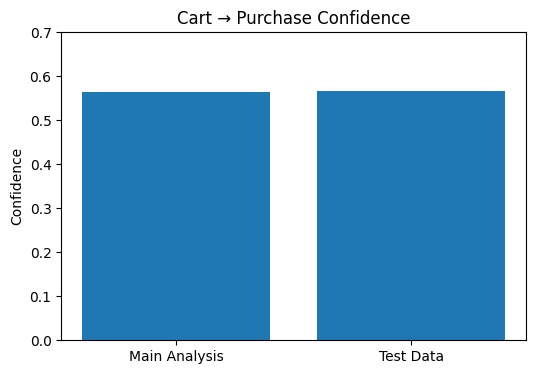

In [ ]:
confidence_values = [
    0.5633,
    0.5662
]

names = [
    "Main Analysis",
    "Test Data"
]

plt.figure(figsize=(6,4))

plt.bar(names, confidence_values)

plt.title("Cart → Purchase Confidence")
plt.ylabel("Confidence")

plt.ylim(0, 0.7)

plt.show()